# EP Leverage Throttle v2 — Rolling CVaR Percentile Rank
State-conditional CVaR with **expanding percentile rank** for dynamic leverage on SPY (Vorobets 2025).

**Three-phase walk-forward design (no look-ahead bias):**

| Phase | Duration | VIX Thresholds | FFR | CVaR Ranking | Trading |
|-------|----------|----------------|-----|--------------|---------|
| **Phase 0** — VIX Calibration | 504d (~2yr) | Rolling 504d window | None | None | None |
| **Phase 1** — CVaR Collection | 504d (~2yr) | Rolling 504d (continues) | On regime change | Collect obs, no decisions | None |
| **Phase 2** — Live Evaluation | Remainder | Rolling 504d (continues) | On regime change | Expanding percentile rank → leverage | Yes |

**Key properties:**
- VIX P25/P75 use **rolling 504d window** — adaptive to VIX's long-run trend
- CVaR ranking pool is **expanding** (all observations from Phase 1 onward)
- Percentile rank is scale-invariant: 0–1 regardless of pool size (no z-score compression)
- Rank < 0.25 → calm → 1.5x | 0.25–0.75 → normal → 1.0x | ≥ 0.75 → stressed → 0.5x
- SMA 200 bear override → 0.0x | 10bps TC per leverage change

In [7]:
import numpy as np
import pandas as pd
import yfinance as yf
import fortitudo.tech as ft
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

## 1 — Data

In [8]:
raw = yf.download(['SPY', '^VIX'], start='1993-01-01', auto_adjust=True)['Close']
raw.columns = ['SPY', 'VIX']
raw = raw.dropna()

df = pd.DataFrame(index=raw.index)
df['spy_close'] = raw['SPY']
df['vix_close'] = raw['VIX']
df['spy_ret'] = df['spy_close'].pct_change()
df['spy_log_ret'] = np.log(df['spy_close'] / df['spy_close'].shift(1))
df['sma_200'] = df['spy_close'].rolling(window=200).mean()
df = df.dropna()

print(f'Data: {df.index[0].date()} to {df.index[-1].date()} ({len(df)} days)')

[*********************100%***********************]  2 of 2 completed

Data: 1993-11-11 to 2026-03-09 (8134 days)


## 2 — Configuration

In [9]:
# ── CONFIGURE ─────────────────────────────────────────────────────
H = 21                          # forward horizon (trading days)
S_SIM = 10000                   # simulation paths per state
ALPHA = 0.90                    # CVaR confidence level
TC_BPS = 0.0010                 # transaction cost per leverage change

# State variable: VIX percentile thresholds (rolling window)
VIX_LO_PCT = 25                # below this = Low VIX state
VIX_HI_PCT = 75                # above this = High VIX state
N_STATES = 3                   # Low, Mid, High
VIX_WINDOW = 504               # rolling window for VIX percentiles (~2yr)

# Three-phase walk-forward
PHASE0_DAYS = 504              # Phase 0: VIX calibration only (~2yr)
PHASE1_DAYS = 504              # Phase 1: CVaR collection, no trading (~2yr)
                               # Phase 2: live trading (remainder)

# v2: Expanding CVaR percentile rank → leverage mapping
RANK_LO = 0.25                 # below this = calm → high leverage
RANK_HI = 0.75                 # above this = stressed → low leverage
LEV_STEPS = [1.5, 1.0, 0.5]   # leverage for [calm, normal, stressed]

SEED = 42
# ─────────────────────────────────────────────────────────────────
print(f'Horizon: {H}d | Sims: {S_SIM:,} | CVaR α: {ALPHA}')
print(f'VIX window: rolling {VIX_WINDOW}d | CVaR ranking: expanding')
print(f'Phase 0: {PHASE0_DAYS}d VIX calibration | Phase 1: {PHASE1_DAYS}d CVaR collection')
print(f'Rank bands: [{RANK_LO}, {RANK_HI}] → Leverage: {LEV_STEPS}')

Horizon: 21d | Sims: 10,000 | CVaR α: 0.9
VIX window: rolling 504d | CVaR ranking: expanding
Phase 0: 504d VIX calibration | Phase 1: 504d CVaR collection
Rank bands: [0.25, 0.75] → Leverage: [1.5, 1.0, 0.5]


## 3 — EP State-Conditional Resampling Engine
Identical to v1 — Vorobets (2025) Chapter 3.2.1.

In [10]:
def classify_vix_states(vix_series):
    """Classify VIX into Low/Mid/High using percentiles of the given series."""
    v25 = np.percentile(vix_series, VIX_LO_PCT)
    v75 = np.percentile(vix_series, VIX_HI_PCT)
    states = np.ones(len(vix_series), dtype=int)  # default Mid
    states[vix_series <= v25] = 0  # Low
    states[vix_series > v75] = 2   # High
    return states, v25, v75


def compute_state_probs(log_returns, vix_series, states_vector):
    """Compute EP state-conditional probability vectors (Vorobets style)."""
    T = len(log_returns)
    ret_df = pd.DataFrame(log_returns, columns=['SPY'])
    p_exp = ft.exp_decay_probs(ret_df, half_life=T / 2)
    
    states_prob = np.zeros((T, N_STATES))
    
    for state in range(N_STATES):
        mask = states_vector == state
        if mask.sum() < 10:
            states_prob[:, state] = p_exp[:, 0]
            continue
        
        mu_s = np.mean(vix_series[mask])
        sigma_s = np.std(vix_series[mask])
        
        A = np.vstack((np.ones((1, T)), vix_series[np.newaxis, :]))
        b = np.array([[1.0], [mu_s]])
        G = (vix_series ** 2)[np.newaxis, :]
        h = np.array([[sigma_s ** 2 + mu_s ** 2]])
        
        q = ft.entropy_pooling(p_exp, A, b, G, h)
        states_prob[:, state] = q[:, 0]
    
    return states_prob


def resample_paths(S, H, initial_state, states_prob, states_vector, log_returns):
    """Fully Flexible Resampling: simulate S paths of H days."""
    T = len(log_returns)
    t_indices = np.arange(T)
    sim_returns = np.zeros((S, H))
    
    for s in range(S):
        current_state = initial_state
        for h_step in range(H):
            p_state = states_prob[:, current_state]
            p_state = np.maximum(p_state, 0)
            p_state /= p_state.sum()
            idx = np.random.choice(t_indices, p=p_state)
            sim_returns[s, h_step] = log_returns[idx]
            current_state = states_vector[idx]
    
    return sim_returns.sum(axis=1)


def compute_cvar(returns, alpha=0.90):
    """Compute CVaR (expected shortfall) at given confidence level."""
    threshold = np.percentile(returns, (1 - alpha) * 100)
    return -returns[returns <= threshold].mean()


def cvar_percentile_rank(cvar_val, cvar_history, window):
    """Compute rolling percentile rank of current CVaR within recent history.

    Returns a value in [0, 1] where:
      0 = lowest CVaR (calmest) in the rolling window
      1 = highest CVaR (most stressed) in the rolling window

    Uses scipy-style percentile rank: fraction of values strictly below,
    plus half the fraction of values equal (handles ties properly).
    """
    recent = np.array(cvar_history[-window:]) if len(cvar_history) > window else np.array(cvar_history)
    n = len(recent)
    if n < 2:
        return 0.5  # not enough history — return neutral
    below = np.sum(recent < cvar_val)
    equal = np.sum(recent == cvar_val)
    rank = (below + 0.5 * equal) / n
    return rank


print('EP engine defined.')

EP engine defined.


## 4 — Three-Phase Walk-Forward Backtest

**Phase 0 — VIX Calibration** (days 0–503): Compute expanding VIX percentiles daily.
No FFR, no CVaR, no trading. Establishes state boundaries without look-ahead bias.

**Phase 1 — CVaR Collection** (days 504–1007): VIX thresholds keep expanding.
FFR fires on regime change only. CVaR observations stored to seed the ranking pool.
No trading — just building the distribution.

**Phase 2 — Live Evaluation** (day 1008+): VIX thresholds keep expanding.
FFR fires on regime change. CVaR ranked against expanding pool (all Phase 1 + Phase 2 obs).
Percentile rank → leverage. Trading begins.

In [11]:
np.random.seed(SEED)

all_dates = df.index.tolist()
N = len(df)
state_labels = ['Low', 'Mid', 'High']

phase1_start = PHASE0_DAYS               # first index for Phase 1
phase2_start = PHASE0_DAYS + PHASE1_DAYS  # first index for Phase 2

print(f'Dataset: {N} days ({all_dates[0].date()} → {all_dates[-1].date()})')
print(f'Phase 0: idx 0–{phase1_start-1} ({all_dates[0].date()} → {all_dates[phase1_start-1].date()})')
print(f'Phase 1: idx {phase1_start}–{phase2_start-1} ({all_dates[phase1_start].date()} → {all_dates[phase2_start-1].date()})')
print(f'Phase 2: idx {phase2_start}–{N-1} ({all_dates[phase2_start].date()} → {all_dates[-1].date()})')

# ── Rolling VIX states for ALL days from Phase 0 end onward ──────
# VIX thresholds use rolling 504d window — adaptive to VIX trend
daily_states = np.full(N, -1, dtype=int)
daily_v25 = np.full(N, np.nan)
daily_v75 = np.full(N, np.nan)

for t in range(PHASE0_DAYS, N):
    # Rolling window: last VIX_WINDOW days up to and including t
    win_start = max(0, t + 1 - VIX_WINDOW)
    vix_window = df['vix_close'].values[win_start:t + 1]
    v25 = np.percentile(vix_window, VIX_LO_PCT)
    v75 = np.percentile(vix_window, VIX_HI_PCT)
    daily_v25[t] = v25
    daily_v75[t] = v75
    vix_now = df['vix_close'].values[t]
    if vix_now <= v25:
        daily_states[t] = 0
    elif vix_now > v75:
        daily_states[t] = 2
    else:
        daily_states[t] = 1

print(f'\nRolling {VIX_WINDOW}d VIX states computed for {(daily_states >= 0).sum()} days.')

# Count regime changes
p1_states = daily_states[phase1_start:phase2_start]
p2_states = daily_states[phase2_start:]
print(f'Regime changes — Phase 1: {(np.diff(p1_states) != 0).sum()} | Phase 2: {(np.diff(p2_states) != 0).sum()}')

# ── Phase 1: CVaR Collection — FFR on regime change ─────────────
print(f'\n{"="*60}')
print(f'=== Phase 1: CVaR Collection ({all_dates[phase1_start].date()} → {all_dates[phase2_start-1].date()}) ===')
print(f'FFR on regime change only. No trading.')

ffr_records = []
cvar_history = []  # expanding pool of all CVaR observations

prev_state = daily_states[phase1_start - 1]
phase1_ffr_count = 0

for t in range(phase1_start, phase2_start):
    current_state = daily_states[t]
    regime_changed = (current_state != prev_state)
    
    if regime_changed:
        vix_train = df['vix_close'].values[:t + 1]
        ret_train = df['spy_log_ret'].values[:t + 1]
        states_vec, v25, v75 = classify_vix_states(vix_train)
        
        states_prob = compute_state_probs(ret_train, vix_train, states_vec)
        cum_returns = resample_paths(S_SIM, H, current_state, states_prob, states_vec, ret_train)
        cvar_val = compute_cvar(cum_returns, alpha=ALPHA)
        cvar_history.append(cvar_val)
        phase1_ffr_count += 1
        
        ffr_records.append({
            'date': all_dates[t], 'idx': t, 'phase': 'collection',
            'train_size': t + 1, 'vix': vix_train[-1],
            'vix_state': current_state, 'v25': v25, 'v75': v75,
            'cvar': cvar_val, 'rank': np.nan,
            'sma_bear': df['spy_close'].iloc[t] < df['sma_200'].iloc[t],
        })
        
        if phase1_ffr_count % 10 == 0:
            print(f'  Phase 1 FFR #{phase1_ffr_count} | {all_dates[t].date()} | '
                  f'VIX={vix_train[-1]:.1f} ({state_labels[prev_state]}→{state_labels[current_state]}) | '
                  f'CVaR={cvar_val:.4f}')
    
    prev_state = current_state

print(f'  Phase 1 complete: {phase1_ffr_count} FFR runs → {len(cvar_history)} CVaR obs in ranking pool')
if len(cvar_history) > 0:
    print(f'  CVaR range: [{min(cvar_history):.4f}, {max(cvar_history):.4f}]')

# ── Phase 2: Live Evaluation — FFR on regime change, trade ───────
print(f'\n{"="*60}')
print(f'=== Phase 2: Live Evaluation ({all_dates[phase2_start].date()} → {all_dates[-1].date()}) ===')
print(f'FFR on regime change. CVaR ranked against expanding pool. Trading.')

prev_state = daily_states[phase2_start - 1]
last_cvar = cvar_history[-1] if cvar_history else 0.0
last_rank = 0.5  # neutral default
ffr_count_eval = 0

for t in range(phase2_start, N):
    current_state = daily_states[t]
    regime_changed = (current_state != prev_state)
    
    if regime_changed:
        vix_train = df['vix_close'].values[:t + 1]
        ret_train = df['spy_log_ret'].values[:t + 1]
        states_vec, v25, v75 = classify_vix_states(vix_train)
        
        states_prob = compute_state_probs(ret_train, vix_train, states_vec)
        cum_returns = resample_paths(S_SIM, H, current_state, states_prob, states_vec, ret_train)
        cvar_val = compute_cvar(cum_returns, alpha=ALPHA)
        cvar_history.append(cvar_val)
        
        rank = cvar_percentile_rank(cvar_val, cvar_history, len(cvar_history))
        last_cvar = cvar_val
        last_rank = rank
        ffr_count_eval += 1
        
        sma_bear = df['spy_close'].iloc[t] < df['sma_200'].iloc[t]
        
        ffr_records.append({
            'date': all_dates[t], 'idx': t, 'phase': 'eval',
            'train_size': t + 1, 'vix': vix_train[-1],
            'vix_state': current_state, 'v25': v25, 'v75': v75,
            'cvar': cvar_val, 'rank': rank, 'sma_bear': sma_bear,
        })
        
        if ffr_count_eval % 25 == 0:
            print(f'  Eval FFR #{ffr_count_eval} | {all_dates[t].date()} | '
                  f'VIX={vix_train[-1]:.1f} ({state_labels[prev_state]}→{state_labels[current_state]}) | '
                  f'CVaR={cvar_val:.4f} | rank={rank:.2f} | pool={len(cvar_history)}')
    
    prev_state = current_state

rebal_df = pd.DataFrame(ffr_records).set_index('date')
print(f'\nDone. {len(rebal_df)} total FFR runs ({len(cvar_history)} CVaR obs in expanding pool).')
print(f'  Phase 1: {phase1_ffr_count} collection | Phase 2: {ffr_count_eval} eval triggers')

Dataset: 8134 days (1993-11-11 → 2026-03-09)
Phase 0: idx 0–503 (1993-11-11 → 1995-11-08)
Phase 1: idx 504–1007 (1995-11-09 → 1997-11-05)
Phase 2: idx 1008–8133 (1997-11-06 → 2026-03-09)

Rolling 504d VIX states computed for 7630 days.
Regime changes — Phase 1: 52 | Phase 2: 909

=== Phase 1: CVaR Collection (1995-11-09 → 1997-11-05) ===
FFR on regime change only. No trading.
  Phase 1 FFR #10 | 1995-12-27 | VIX=12.0 (Low→Mid) | CVaR=0.0374
  Phase 1 FFR #20 | 1996-08-09 | VIX=15.8 (High→Mid) | CVaR=0.0324
  Phase 1 FFR #30 | 1996-10-11 | VIX=15.1 (High→Mid) | CVaR=0.0317
  Phase 1 FFR #40 | 1997-06-12 | VIX=18.5 (High→Mid) | CVaR=0.0273
  Phase 1 FFR #50 | 1997-10-14 | VIX=20.0 (High→Mid) | CVaR=0.0339
  Phase 1 complete: 53 FFR runs → 53 CVaR obs in ranking pool
  CVaR range: [0.0161, 0.0729]

=== Phase 2: Live Evaluation (1997-11-06 → 2026-03-09) ===
FFR on regime change. CVaR ranked against expanding pool. Trading.
  Eval FFR #25 | 1998-11-20 | VIX=22.5 (High→Mid) | CVaR=0.0383 | r

## 5 — Percentile Rank → Leverage Mapping
**v2:** Leverage determined by **expanding percentile rank** of CVaR (P25/P75 cutoffs).
- Rank < 0.25 → calm → 1.5x
- 0.25 ≤ Rank < 0.75 → normal → 1.0x  
- Rank ≥ 0.75 → stressed → 0.5x
- SMA override: SPY < SMA200 → 0.0x

Leverage is forward-filled between regime-change FFR triggers.

In [12]:
def rank_to_leverage(rank, sma_bear):
    """Map CVaR percentile rank to leverage with SMA override."""
    if sma_bear:
        return 0.0
    if rank < RANK_LO:
        return LEV_STEPS[0]   # calm → high leverage
    elif rank < RANK_HI:
        return LEV_STEPS[1]   # normal
    else:
        return LEV_STEPS[2]   # stressed → low leverage


# Evaluation period = Phase 2
eval_start_date = all_dates[phase2_start]
eval_dates = df.index[df.index >= eval_start_date]

eval_ffr = rebal_df[rebal_df['phase'] == 'eval'].copy()

# Build daily rank & CVaR: forward-fill from FFR trigger dates
daily_rank = pd.Series(np.nan, index=eval_dates)
daily_cvar = pd.Series(np.nan, index=eval_dates)

# Seed with neutral rank (0.5) — first regime change will override
daily_rank.iloc[0] = 0.5
daily_cvar.iloc[0] = last_cvar

# Fill in eval FFR trigger dates
for date in eval_ffr.index:
    if date in daily_rank.index:
        daily_rank.loc[date] = eval_ffr.loc[date, 'rank']
        daily_cvar.loc[date] = eval_ffr.loc[date, 'cvar']

daily_rank = daily_rank.ffill()
daily_cvar = daily_cvar.ffill()

# Daily SMA bear flag (using previous day's data — no look-ahead)
daily_sma_bear = df['spy_close'].shift(1) < df['sma_200'].shift(1)
daily_sma_bear = daily_sma_bear.reindex(eval_dates).fillna(False)

# Compute daily leverage
daily_leverage = pd.Series(
    [rank_to_leverage(r, sma) for r, sma in zip(daily_rank, daily_sma_bear)],
    index=eval_dates)

print(f'Evaluation period: {eval_dates[0].date()} to {eval_dates[-1].date()} ({len(eval_dates)} days)')
print(f'CVaR ranking pool at start: {phase1_ffr_count} obs (from Phase 1)')
print(f'\nLeverage distribution:')
for lev in sorted(daily_leverage.unique()):
    n = (daily_leverage == lev).sum()
    print(f'  {lev:.1f}x: {n:5d} days ({n/len(daily_leverage):.1%})')

avg_leverage = daily_leverage.mean()
n_lev_changes = (daily_leverage.diff().abs() > 0).sum()
print(f'\nAverage leverage: {avg_leverage:.3f}x → benchmark buy-and-hold')
print(f'Leverage changes: {n_lev_changes} (from {ffr_count_eval} regime-change FFR triggers)')

Evaluation period: 1997-11-06 to 2026-03-09 (7126 days)
CVaR ranking pool at start: 53 obs (from Phase 1)

Leverage distribution:
  0.0x:  1770 days (24.8%)
  0.5x:  1138 days (16.0%)
  1.0x:  3197 days (44.9%)
  1.5x:  1021 days (14.3%)

Average leverage: 0.743x → benchmark buy-and-hold
Leverage changes: 802 (from 909 regime-change FFR triggers)


## 6 — Backtest: EP Throttle v2 vs Benchmarks

In [13]:
eval_df = df.loc[eval_dates[0]:].copy()

def run_backtest(leverage_series, name):
    """Run backtest with given daily leverage series."""
    equity = 1.0
    prev_lev = 0.0
    records = []
    
    for date in eval_df.index:
        lev = leverage_series.get(date, prev_lev)
        tc = TC_BPS * abs(lev - prev_lev) * equity if lev != prev_lev else 0.0
        equity -= tc
        ret = eval_df.loc[date, 'spy_ret']
        equity *= (1 + lev * ret)
        records.append({'date': date, 'leverage': lev, 'equity': equity,
                        'daily_ret': lev * ret, 'tc': tc})
        prev_lev = lev
    
    return pd.DataFrame(records).set_index('date')


# EP Throttle v2
bt_ep = run_backtest(daily_leverage, 'EP Throttle v2')

# SMA-Only 1.0x
sma_lev = pd.Series(1.0, index=eval_df.index)
sma_lev[eval_df['spy_close'].shift(1) < eval_df['sma_200'].shift(1)] = 0.0
bt_sma = run_backtest(sma_lev, 'SMA-Only 1.0x')

# SPY Buy & Hold 1.0x
bh_lev = pd.Series(1.0, index=eval_df.index)
bt_bh = run_backtest(bh_lev, 'SPY B&H 1.0x')

# Benchmark: constant leverage at average realized leverage
const_avg_lev = pd.Series(avg_leverage, index=eval_df.index)
bt_avg = run_backtest(const_avg_lev, f'B&H {avg_leverage:.2f}x')

strats = {
    'EP Throttle v2': bt_ep,
    'SMA-Only 1.0x': bt_sma,
    'SPY B&H 1.0x': bt_bh,
    f'B&H {avg_leverage:.2f}x': bt_avg,
}

print(f'Evaluation: {eval_df.index[0].date()} to {eval_df.index[-1].date()} ({len(eval_df)} days)')

Evaluation: 1997-11-06 to 2026-03-09 (7126 days)


## 7 — Performance Metrics

In [14]:
def calc_metrics(bt, name):
    n_years = len(bt) / 252
    total_ret = bt['equity'].iloc[-1] - 1
    ann_ret = (1 + total_ret) ** (1 / n_years) - 1
    ann_vol = bt['daily_ret'].std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
    dd = ((bt['equity'] - bt['equity'].cummax()) / bt['equity'].cummax()).min()
    calmar = ann_ret / abs(dd) if dd != 0 else 0
    total_tc = bt['tc'].sum()
    ann_tc_bps = (total_tc / n_years) * 10000
    n_changes = (bt['leverage'].diff().abs() > 0).sum()
    avg_lev = bt['leverage'].mean()
    return {
        'Strategy': name,
        'Ann. Return': f'{ann_ret:.2%}',
        'Ann. Vol': f'{ann_vol:.2%}',
        'Sharpe': f'{sharpe:.2f}',
        'Max DD': f'{dd:.2%}',
        'Calmar': f'{calmar:.2f}',
        'Avg Lev': f'{avg_lev:.2f}',
        'Ann. TC (bps)': f'{ann_tc_bps:.0f}',
        'Lev Changes': n_changes,
    }

tbl = pd.DataFrame([calc_metrics(bt, name) for name, bt in strats.items()]).set_index('Strategy')
print('=== Performance (net of 10bps TC) ===')
print(tbl.to_string())

=== Performance (net of 10bps TC) ===
               Ann. Return Ann. Vol Sharpe   Max DD Calmar Avg Lev Ann. TC (bps)  Lev Changes
Strategy                                                                                     
EP Throttle v2      14.52%   10.81%   1.34  -21.19%   0.69    0.74          1437          802
SMA-Only 1.0x        6.39%   12.00%   0.53  -30.82%   0.21    0.75           124          192
SPY B&H 1.0x         9.10%   19.41%   0.47  -55.19%   0.16    1.00             0            0
B&H 0.74x            7.07%   14.43%   0.49  -43.85%   0.16    0.74             0            0


## 8 — Equity Curves & Drawdowns

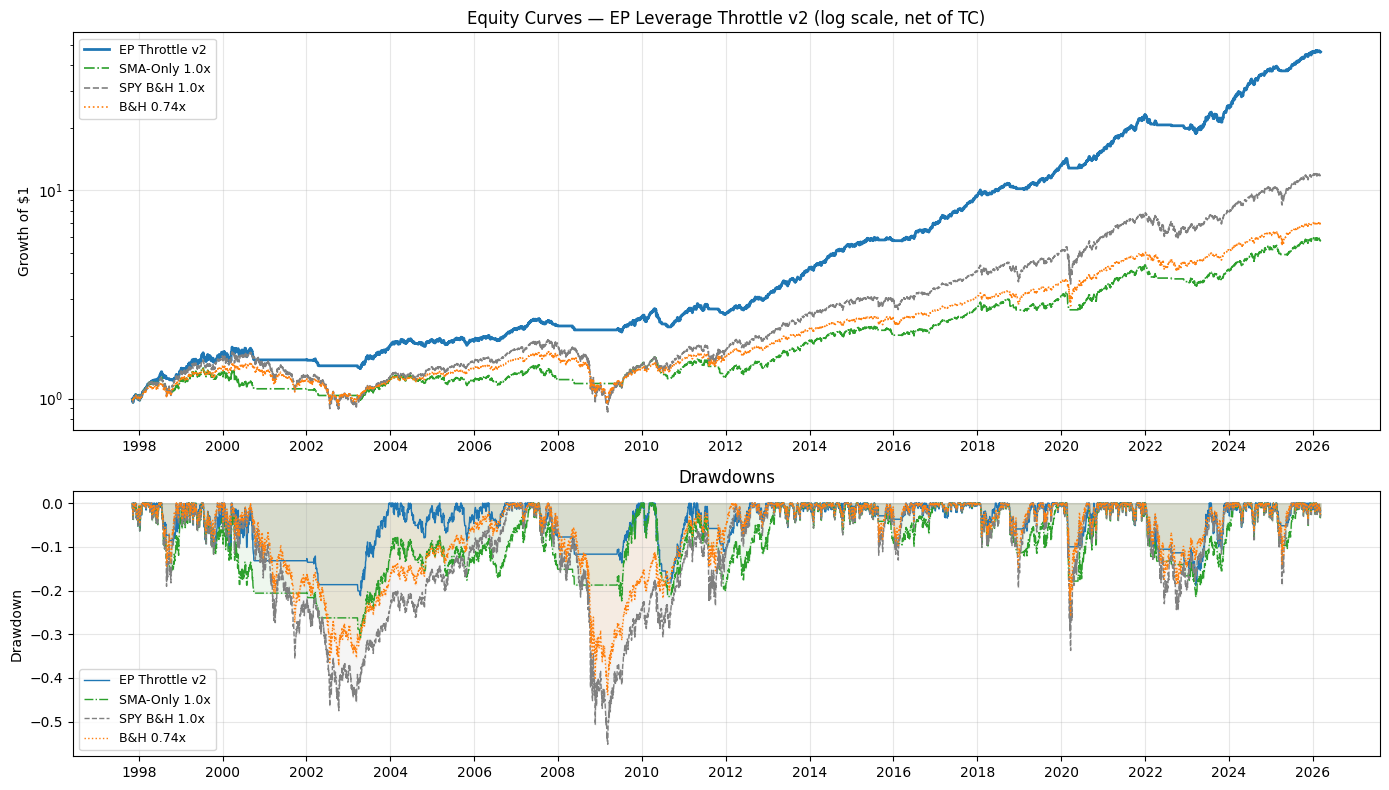

In [15]:
PLOT_STYLES = {
    'EP Throttle v2':   dict(lw=2.0, color='C0', ls='-'),
    'SMA-Only 1.0x':    dict(lw=1.2, color='C2', ls='-.'),
    'SPY B&H 1.0x':     dict(lw=1.2, color='grey', ls='--'),
}
avg_key = f'B&H {avg_leverage:.2f}x'
PLOT_STYLES[avg_key] = dict(lw=1.2, color='C1', ls=':')

fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 2]})

ax = axes[0]
for name, bt in strats.items():
    s = PLOT_STYLES[name]
    ax.plot(bt.index, bt['equity'], label=name, **s)
ax.set_yscale('log')
ax.set_title('Equity Curves — EP Leverage Throttle v2 (log scale, net of TC)')
ax.set_ylabel('Growth of $1')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
for name, bt in strats.items():
    s = PLOT_STYLES[name]
    dd = (bt['equity'] - bt['equity'].cummax()) / bt['equity'].cummax()
    ax.fill_between(bt.index, dd, 0, alpha=0.08, color=s['color'])
    ax.plot(bt.index, dd, label=name, linewidth=1, linestyle=s['ls'], color=s['color'])
ax.set_title('Drawdowns')
ax.set_ylabel('Drawdown')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

for a in axes:
    a.xaxis.set_major_locator(mdates.YearLocator(2))
    a.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

## 9 — CVaR Percentile Rank & Leverage Over Time
**v2 diagnostic panel:** Shows rolling percentile rank instead of z-score.

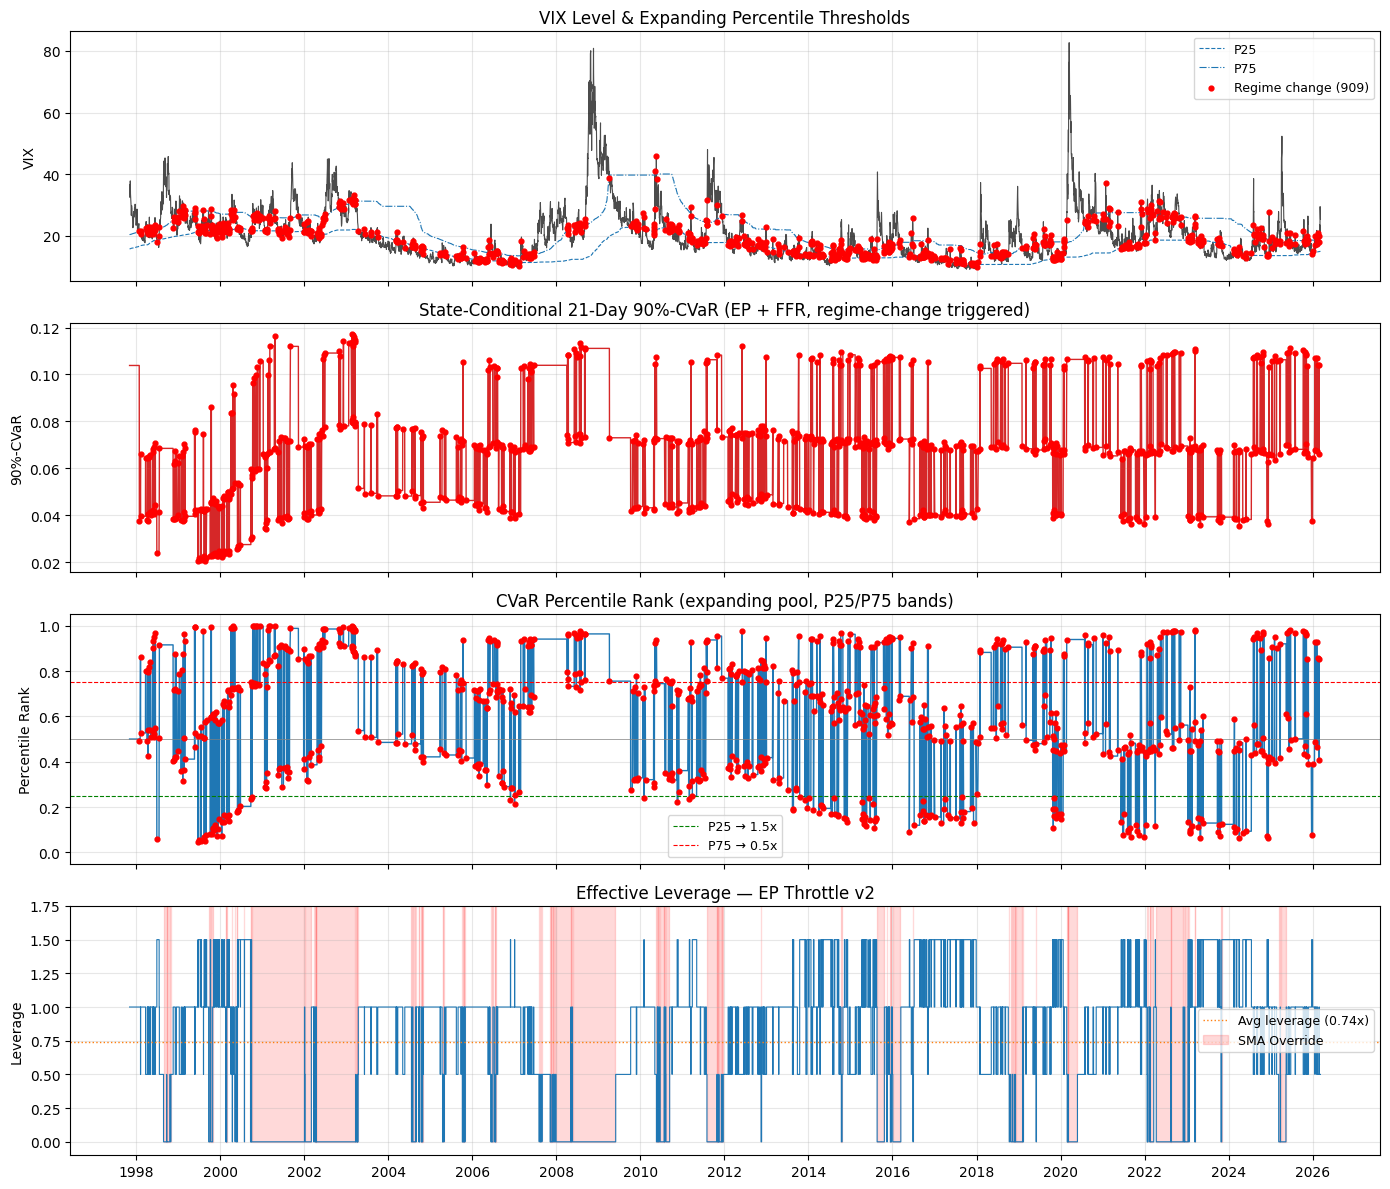

In [16]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

# VIX + expanding percentile thresholds
ax = axes[0]
eval_vix = df.loc[eval_dates[0]:, 'vix_close']
eval_v25 = pd.Series(daily_v25[phase2_start:phase2_start+len(eval_dates)], index=eval_dates)
eval_v75 = pd.Series(daily_v75[phase2_start:phase2_start+len(eval_dates)], index=eval_dates)
ax.plot(eval_vix.index, eval_vix, lw=0.8, color='black', alpha=0.7)
ax.plot(eval_v25.index, eval_v25, color='C0', ls='--', lw=0.8, label=f'P{VIX_LO_PCT}')
ax.plot(eval_v75.index, eval_v75, color='C0', ls='-.', lw=0.8, label=f'P{VIX_HI_PCT}')
eval_ffr_dates = eval_ffr.index
ax.scatter(eval_ffr_dates, df.loc[eval_ffr_dates, 'vix_close'], 
           color='red', s=12, zorder=5, label=f'Regime change ({len(eval_ffr_dates)})')
ax.set_ylabel('VIX')
ax.set_title('VIX Level & Expanding Percentile Thresholds')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# CVaR (forward-filled daily)
ax = axes[1]
ax.plot(daily_cvar.index, daily_cvar, lw=1, color='C3')
ax.scatter(eval_ffr_dates, eval_ffr['cvar'], color='red', s=12, zorder=5)
ax.set_ylabel(f'{int(ALPHA*100)}%-CVaR')
ax.set_title(f'State-Conditional {H}-Day {int(ALPHA*100)}%-CVaR (EP + FFR, regime-change triggered)')
ax.grid(True, alpha=0.3)

# Percentile rank (forward-filled daily)
ax = axes[2]
ax.plot(daily_rank.index, daily_rank, lw=1, color='C0')
ax.axhline(RANK_LO, color='green', ls='--', lw=0.8, label=f'P{int(RANK_LO*100)} → 1.5x')
ax.axhline(RANK_HI, color='red', ls='--', lw=0.8, label=f'P{int(RANK_HI*100)} → 0.5x')
ax.axhline(0.5, color='grey', lw=0.5)
ax.scatter(eval_ffr_dates, eval_ffr['rank'], color='red', s=12, zorder=5)
ax.set_ylabel('Percentile Rank')
ax.set_ylim(-0.05, 1.05)
ax.set_title(f'CVaR Percentile Rank (expanding pool, P25/P75 bands)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Leverage
ax = axes[3]
ax.step(daily_leverage.index, daily_leverage.values, where='post', lw=0.8, color='C0')
ax.axhline(avg_leverage, color='C1', ls=':', lw=1, label=f'Avg leverage ({avg_leverage:.2f}x)')
ax.fill_between(daily_leverage.index, 0, 1.75, where=daily_sma_bear, alpha=0.15, color='red', label='SMA Override')
ax.set_ylabel('Leverage')
ax.set_title('Effective Leverage — EP Throttle v2')
ax.set_ylim(-0.1, 1.75)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

## 10 — Crisis Analysis

In [17]:
crises = [
    ('Dot-com crash', '2000-03-24', '2002-10-09'),
    ('GFC',           '2007-10-09', '2009-03-09'),
    ('COVID',         '2020-02-19', '2020-03-23'),
    ('2022 Bear',     '2022-01-03', '2022-10-12'),
    ('2018 Q4',       '2018-09-20', '2018-12-24'),
]

print('--- Crisis Drawdowns ---')
for crisis, start, end in crises:
    print(f'\n{crisis} ({start} to {end}):')
    for name, bt in strats.items():
        sub = bt[(bt.index >= start) & (bt.index <= end)]
        if len(sub) > 0:
            dd = ((sub['equity'] - sub['equity'].cummax()) / sub['equity'].cummax()).min()
            print(f'  {name:20s} | DD: {dd:.2%}')

--- Crisis Drawdowns ---

Dot-com crash (2000-03-24 to 2002-10-09):
  EP Throttle v2       | DD: -18.65%
  SMA-Only 1.0x        | DD: -24.94%
  SPY B&H 1.0x         | DD: -47.52%
  B&H 0.74x            | DD: -37.24%

GFC (2007-10-09 to 2009-03-09):
  EP Throttle v2       | DD: -9.78%
  SMA-Only 1.0x        | DD: -15.09%
  SPY B&H 1.0x         | DD: -55.19%
  B&H 0.74x            | DD: -43.85%

COVID (2020-02-19 to 2020-03-23):
  EP Throttle v2       | DD: -9.98%
  SMA-Only 1.0x        | DD: -17.84%
  SPY B&H 1.0x         | DD: -33.72%
  B&H 0.74x            | DD: -25.91%

2022 Bear (2022-01-03 to 2022-10-12):
  EP Throttle v2       | DD: -11.36%
  SMA-Only 1.0x        | DD: -14.06%
  SPY B&H 1.0x         | DD: -24.50%
  B&H 0.74x            | DD: -18.50%

2018 Q4 (2018-09-20 to 2018-12-24):
  EP Throttle v2       | DD: -5.90%
  SMA-Only 1.0x        | DD: -11.31%
  SPY B&H 1.0x         | DD: -19.35%
  B&H 0.74x            | DD: -14.68%


## 11 — State-Conditional Return Distributions (KDE)

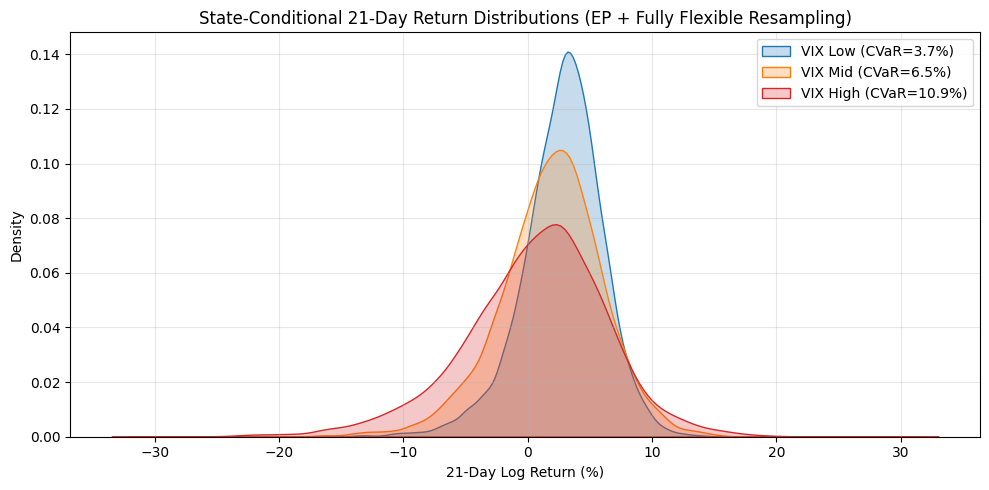

In [18]:
vix_final = df['vix_close'].values
ret_final = df['spy_log_ret'].values
states_final, _, _ = classify_vix_states(vix_final)
states_prob_final = compute_state_probs(ret_final, vix_final, states_final)

np.random.seed(SEED)
state_labels_kde = ['VIX Low', 'VIX Mid', 'VIX High']
state_colors = ['C0', 'C1', 'C3']

fig, ax = plt.subplots(figsize=(10, 5))
for state in range(N_STATES):
    cum_ret = resample_paths(S_SIM, H, state, states_prob_final, states_final, ret_final)
    cvar = compute_cvar(cum_ret, ALPHA)
    sns.kdeplot(100 * cum_ret, ax=ax, color=state_colors[state], fill=True, alpha=0.25,
                label=f'{state_labels_kde[state]} (CVaR={100*cvar:.1f}%)')

ax.set_xlabel(f'{H}-Day Log Return (%)')
ax.set_title(f'State-Conditional {H}-Day Return Distributions (EP + Fully Flexible Resampling)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12 — Transition Matrix

In [19]:
transition_matrix = np.zeros((N_STATES, N_STATES))
for row_state in range(N_STATES):
    for col_state in range(N_STATES):
        transition_matrix[row_state, col_state] = np.sum(
            states_prob_final[states_final == col_state, row_state])

print('State Transition Matrix (rows = from, cols = to):')
trans_df = pd.DataFrame(
    np.round(transition_matrix, 3),
    index=['From Low', 'From Mid', 'From High'],
    columns=['To Low', 'To Mid', 'To High'])
trans_df

State Transition Matrix (rows = from, cols = to):


,To Low,To Mid,To High
From Low,0.942,0.058,0.000
From Mid,0.057,0.915,0.028
From High,0.013,0.193,0.795


## 13 — CVaR Pool Diagnostics
How the expanding CVaR pool evolves: Phase 1 (collection, no trading) vs Phase 2 (eval, trading).

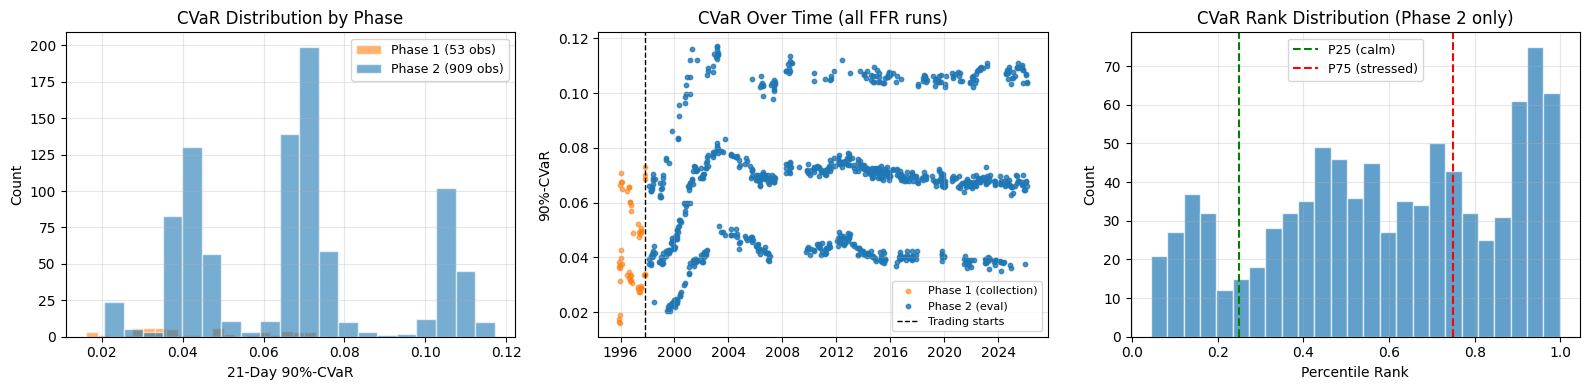

Phase 1 CVaR pool: 53 obs | range [0.0161, 0.0729] | mean 0.0436
Phase 2 CVaR pool: 909 obs | range [0.0205, 0.1172] | mean 0.0669

Phase 2 rank distribution:
  < P25 (calm → 1.5x):     15.4%
  P25–P75 (normal → 1.0x): 50.9%
  ≥ P75 (stressed → 0.5x): 33.7%
  Expanding pool size at end: 962


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# CVaR distribution: Phase 1 vs Phase 2
collection_cvars = rebal_df[rebal_df['phase'] == 'collection']['cvar']
eval_cvars = rebal_df[rebal_df['phase'] == 'eval']['cvar']

ax = axes[0]
ax.hist(collection_cvars, bins=20, alpha=0.6, color='C1', edgecolor='white', label=f'Phase 1 ({len(collection_cvars)} obs)')
ax.hist(eval_cvars, bins=20, alpha=0.6, color='C0', edgecolor='white', label=f'Phase 2 ({len(eval_cvars)} obs)')
ax.set_xlabel(f'{H}-Day {int(ALPHA*100)}%-CVaR')
ax.set_ylabel('Count')
ax.set_title('CVaR Distribution by Phase')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# CVaR over time (all FFR runs)
ax = axes[1]
ax.scatter(collection_cvars.index, collection_cvars, s=10, color='C1', alpha=0.6, label='Phase 1 (collection)')
ax.scatter(eval_cvars.index, eval_cvars, s=10, color='C0', alpha=0.8, label='Phase 2 (eval)')
ax.axvline(all_dates[phase2_start], color='black', ls='--', lw=1, label='Trading starts')
ax.set_ylabel(f'{int(ALPHA*100)}%-CVaR')
ax.set_title('CVaR Over Time (all FFR runs)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Rank distribution (eval only — Phase 1 has no ranks)
ax = axes[2]
eval_ranks = eval_ffr['rank'].dropna()
ax.hist(eval_ranks, bins=25, color='C0', alpha=0.7, edgecolor='white')
ax.axvline(RANK_LO, color='green', ls='--', lw=1.5, label=f'P{int(RANK_LO*100)} (calm)')
ax.axvline(RANK_HI, color='red', ls='--', lw=1.5, label=f'P{int(RANK_HI*100)} (stressed)')
ax.set_xlabel('Percentile Rank')
ax.set_ylabel('Count')
ax.set_title('CVaR Rank Distribution (Phase 2 only)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary stats
print(f'Phase 1 CVaR pool: {len(collection_cvars)} obs | '
      f'range [{collection_cvars.min():.4f}, {collection_cvars.max():.4f}] | '
      f'mean {collection_cvars.mean():.4f}')
print(f'Phase 2 CVaR pool: {len(eval_cvars)} obs | '
      f'range [{eval_cvars.min():.4f}, {eval_cvars.max():.4f}] | '
      f'mean {eval_cvars.mean():.4f}')
print(f'\nPhase 2 rank distribution:')
print(f'  < P{int(RANK_LO*100)} (calm → 1.5x):     {(eval_ranks < RANK_LO).mean():.1%}')
print(f'  P{int(RANK_LO*100)}–P{int(RANK_HI*100)} (normal → 1.0x): {((eval_ranks >= RANK_LO) & (eval_ranks < RANK_HI)).mean():.1%}')
print(f'  ≥ P{int(RANK_HI*100)} (stressed → 0.5x): {(eval_ranks >= RANK_HI).mean():.1%}')
print(f'  Expanding pool size at end: {len(cvar_history)}')